**Equations and Assumptions Used for Estimation**

1. The vehicle draws approximately constant average power $P_{\mathrm{sys}}$ over the flight.

2. We target a fixed flight time
$T_{\mathrm{target}} = 10~\mathrm{min} = \dfrac{10}{60}~\mathrm{h}$.

3. Battery mass is $m_b$ in grams; in kilograms
$$m_b^{(\mathrm{kg})} = \dfrac{m_b}{1000}.$$
And the battery is characterized by a single specific energy $e_{\mathrm{batt}}$ (Wh/kg), independent of state-of-charge and discharge rate (we are plotting the requirement, not a particular cell).

4. The discharge power limit scales with battery mass as $3~\mathrm{W/g}$:
$$P_{\max} = 3.0 \cdot m_b \quad [\mathrm{W}],$$
We use this to distinguish ```within battery limits``` vs ```exceeds battery limits``` (solid vs dashed).

5. Coin-Copter power scaling vs mass in the model:
$$
P_{\mathrm{sub}}(m_b) = 1.03\left(\frac{0.688 + m_b}{0.77}\right)^{1/0.596}~\mathrm{W},
$$
$$
P_{\mathrm{gram}}(m_b) = 1.03\left(\frac{1.0 + m_b}{2.11}\right)^{1/0.61}~\mathrm{W},
$$
$$
P_{\mathrm{multi}}(m_b) = 1.03\left(\frac{1.64 + m_b}{2.81}\right)^{1/0.54}~\mathrm{W},
$$
where $m_b$ is in grams and the constants are normalization terms for each variant.

**Required battery specific energy for a 10-min flight**

1. For a given average system power $P_{\mathrm{sys}}$ and target time $T_{\mathrm{target}}$, the required battery energy is
$$
E_{\mathrm{req}}(P_{\mathrm{sys}}) = P_{\mathrm{sys}}\,T_{\mathrm{target}} \quad [\mathrm{Wh}].
$$

2. Dividing by battery mass in kg gives the required specific energy in Wh/kg:
$$
e_{\mathrm{req}}(m_b)
= \frac{E_{\mathrm{req}}}{m_b^{(\mathrm{kg})}}
= \frac{P_{\mathrm{sys}}(m_b)\,T_{\mathrm{target}}}{m_b/1000}
= \frac{1000\,P_{\mathrm{sys}}(m_b)\,T_{\mathrm{target}}}{m_b}
\quad [\mathrm{Wh/kg}].
$$
Because
$$
1~\mathrm{Wh/kg} = 1~\mathrm{mWh/g},
$$
we can equivalently interpret this as mWh/g:
$$
e_{\mathrm{req}}(m_b)\ [\mathrm{mWh/g}]
= \frac{1000\,P_{\mathrm{sys}}(m_b)\,T_{\mathrm{target}}}{m_b}.
$$

3. In the code we set $T_{\mathrm{target}} = 10~\mathrm{min} = 10/60~\mathrm{h}$ and plot the parametric curves
$$
\bigl(P_{\mathrm{sys}}(m_b),\, e_{\mathrm{req}}(m_b)\bigr)
$$
for each design, using the discharge-limit condition
$$
P_{\mathrm{sys}}(m_b) < P_{\max}(m_b)
$$
to decide solid vs dashed segments.


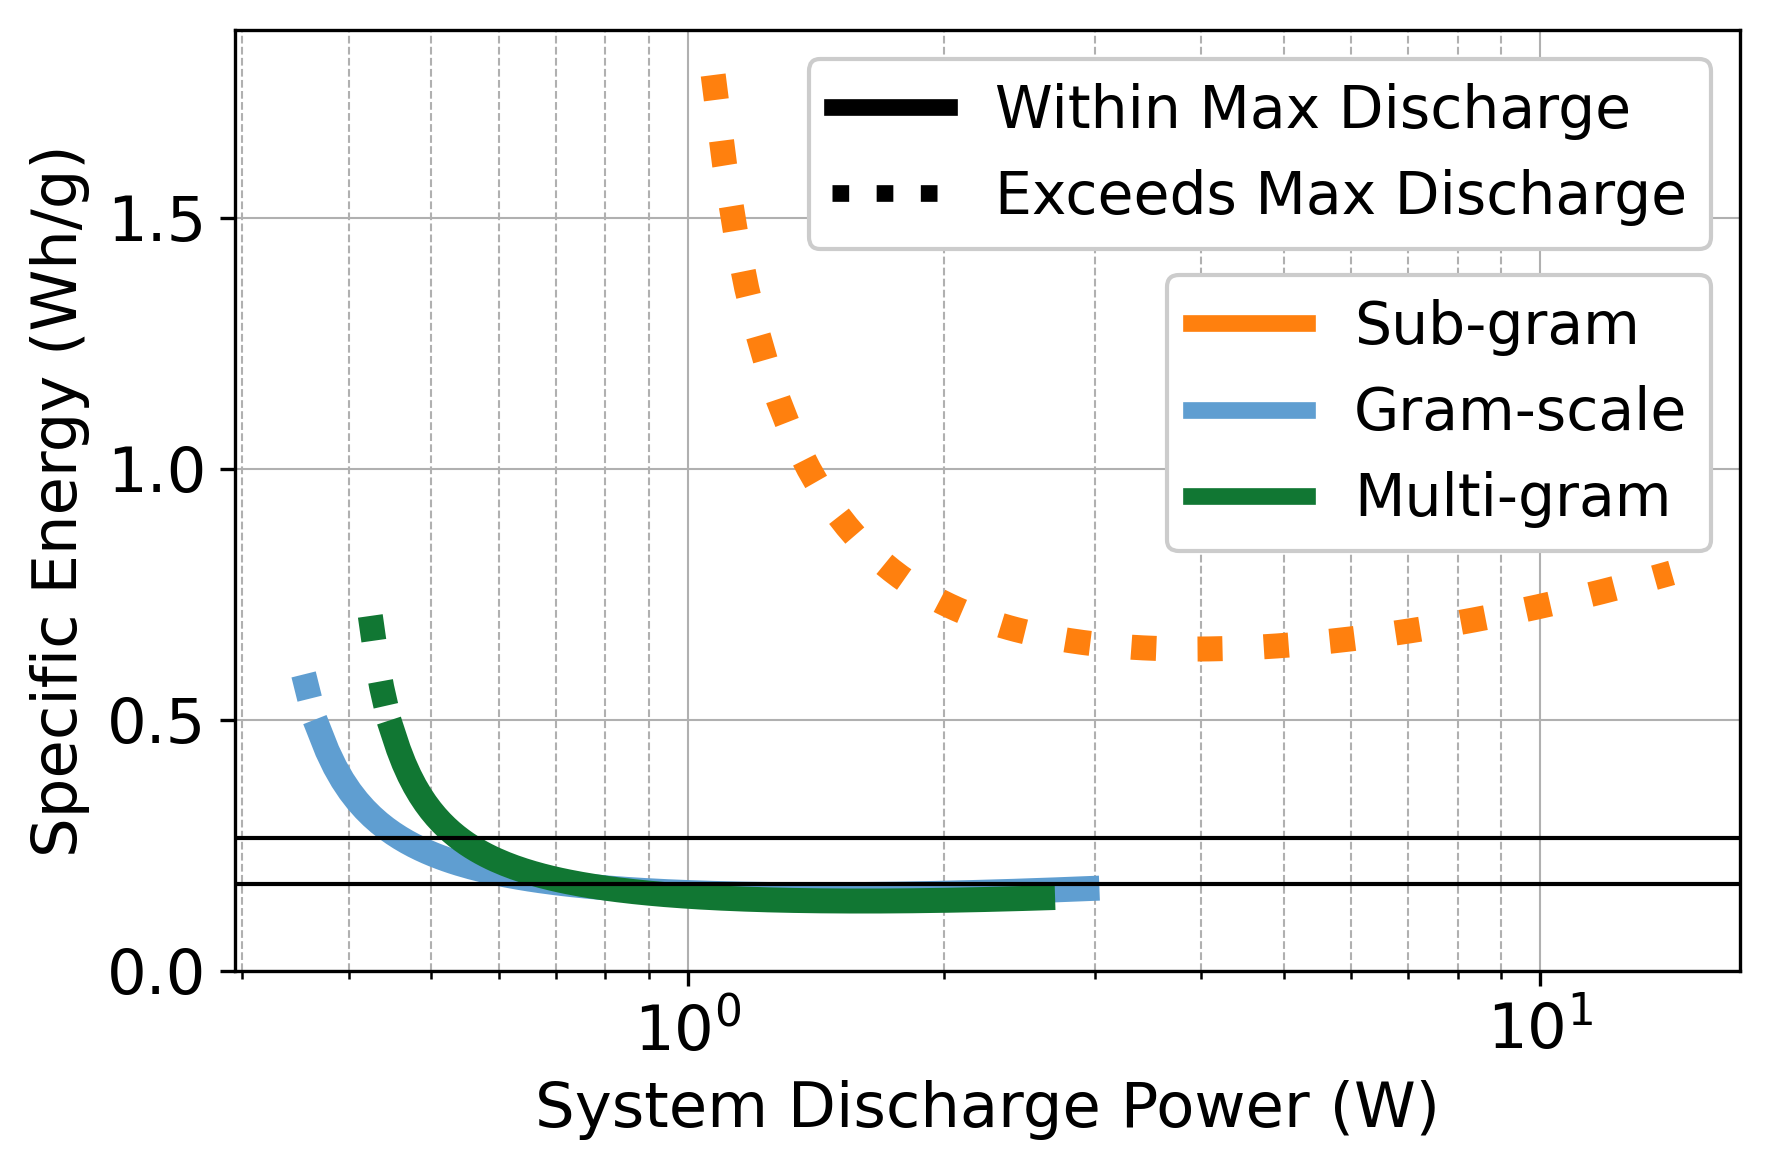

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Battery mass range in grams (100 mg to 3000 mg)
masses = np.linspace(0.1, 3.0, 200)

# Max battery discharge power (W), 3 W/g
P_max = 2.9 * masses

# Average consumed power for each category (W), same as before
P_avg = {
    'Sub-gram': ((0.688 + masses) / 0.77) ** (1/0.596) * 1.03,
    'Gram-scale': ((1.0 + masses) / 2.11) ** (1/0.61) * 1.03,
    'Multi-gram': ((1.64 + masses) / 2.81) ** (1/0.54) * 1.03
}

# Target flight time
t_target_min = 10.0
t_target_hr = t_target_min / 60.0  # hours

# Required battery specific energy (mWh/g) for 10-min flight
def compute_required_specific_energy(P_avg_vals, masses_g):
    # P_avg_vals in W, masses_g in g
    # e_req [mWh/g] = (P * t[h] / (m[g]/1000 kg)) = 1000*P*t / m[g]
    return P_avg_vals * t_target_hr * 1000.0 / masses_g

E_spec = {name: compute_required_specific_energy(vals, masses)
          for name, vals in P_avg.items()}

# Feasibility based on discharge power limit
feasibility = {name: (P_max > vals) for name, vals in P_avg.items()}

# Helper to find contiguous segments for solid/dashed plotting
def get_segments(x_vals, y_vals, mask):
    segments = []
    start = None
    for i in range(len(mask)):
        if mask[i]:
            if start is None:
                start = i
        else:
            if start is not None:
                segments.append((x_vals[start:i], y_vals[start:i]))
                start = None
    if start is not None:
        segments.append((x_vals[start:], y_vals[start:]))
    return segments

# Plot
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
# Define a manual color scheme  |  ['006BA4', 'FF800E', 'ABABAB', '595959', '5F9ED1', 'C85200', '898989', 'A2C8EC', 'FFBC79', 'CFCFCF']
colors = {
    "Sub-gram":   "#FF800E",
    "Gram-scale": "#5F9ED1",
    "Multi-gram": "#117733"
}

for name, color in colors.items():
    P_vals = P_avg[name]        # x-axis: system discharge power (W)
    Es_vals = E_spec[name]      # y-axis: required specific energy (mWh/g)
    feas = feasibility[name]

    # Feasible segments (solid)
    for seg_x, seg_y in get_segments(P_vals, Es_vals, feas):
        ax.plot(seg_x, seg_y/1000, color=color, linewidth=6, zorder=3)

    # Infeasible segments (dashed)
    infeas = ~feas
    for seg_x, seg_y in get_segments(P_vals, Es_vals, infeas):
        ax.plot(seg_x, seg_y/1000, color=color, linestyle=':', linewidth=6, zorder=2)

# Legend handles
design_handles = [mlines.Line2D([], [], color=c, lw=4, label=nm)
                  for nm, c in colors.items()]
marker_handles = [
    mlines.Line2D([], [], color='black', linestyle='-', linewidth=4,
                  label='Within Max Discharge'),
    mlines.Line2D([], [], color='black', linestyle=':', linewidth=4,
                  label='Exceeds Max Discharge')
]

legend1 = ax.legend(handles=design_handles, loc='upper right',
                    bbox_to_anchor=(1, 0.77),
                    facecolor='white', framealpha=1, fontsize=14)
legend2 = ax.legend(handles=marker_handles, loc='upper right',
                    bbox_to_anchor=(1, 1),
                    facecolor='white', framealpha=1, fontsize=14)
ax.add_artist(legend1)

# Axes styling
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xscale('log')

max_spec = max(max(vals) for vals in E_spec.values())
ax.set_ylim(0, math.ceil(max_spec) * 1.05 / 1000)

ax.set_xlabel("System Discharge Power (W)", fontsize=15)
ax.set_ylabel("Specific Energy (Wh/g)", # for 10 min flight Required Battery \n
              fontsize=15)

# Grids: solid major, dashed minor
ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.5)
ax.grid(True, which='minor', axis='both', linestyle='--', linewidth=0.5)

# Add horizontal lines at: 172 mWh/g (PowerStream upper bound) and 264 mWh/g ()
# 440 mWh/g (https://doi.org/10.1002/adfm.201903003)
# ∼0.65 Wh/g at 1 C (280 mA/g)
# ∼0.57 Wh/g at 5 C (1,400 mA/g)
# ∼0.44 Wh/g at 20 C (5,6 00 mA/g)
ax.axhline(y=0.172, color='black', linestyle='-', linewidth=1, zorder=3)
ax.axhline(y=0.264, color='black', linestyle='-', linewidth=1, zorder=3)
#ax.axhline(y=0.57, color='black', linestyle='-', linewidth=1, zorder=3)

plt.tight_layout()
plt.show()